## Fase 2 - entrenamiento final y evaluacion sobre test (MTL VGG16)

Se entrena con **train**, se monitoriza con **val** y se evalua una sola vez sobre **test**. Como `df_trainval = concat(df_train, df_val)`, se pasan a `train_one_fold` los indices de train y de val originales.

Salidas: metricas finales de las 3 tareas sobre test y CSV de predicciones imagen a imagen (3 tareas con probabilidades) para el estudio estadistico.

 ## MTL - VGG16 (CUT_LAYER=7) + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)


### Nota importante:
# He eliminado ISIC_0028189 del conjunto de train, porque era corrupta.

2026-06-23 20:41:57.289283: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 7
N_FOLDS     = 5
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CUT_LAYER   = 7

WARMUP_EPOCHS, FT_EPOCHS = 30, 30
WARMUP_LR = 1e-3

#LRs diferenciales para fine-tuning (en lugar de un único FT_LR=5e-5)
FT_LR_BACKBONE_LOW  = 5e-6   # capas bajas del backbone (i < CUT_LAYER//2)
FT_LR_BACKBONE_HIGH = 1e-5   # capas altas del backbone (CUT_LAYER//2 <= i < CUT_LAYER)
FT_LR_HEADS         = 1e-4   # shared_dense + cabezas

EXP_DIR = Path("VGG16_MTL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_CUT{CUT_LAYER}_{N_FOLDS}fold_v2"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento en: {EXP_DIR.resolve()}")

Experimento en: /home/marc/MARIADELMAR_EXPERIMENTS/MTL_experimentos/VGG16_MTL/exp_2026-06-23_20-41_CUT7_5fold_v2


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)
df_sym   = pd.read_csv("/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv")

print(f"Disease CSVs   - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")
print(f"Symmetry CSV   - total: {len(df_sym)}")

df_sym = df_sym.rename(columns={"image": "image_id"})
df_sym = df_sym[["image_id", "shape_symmetry"]]

MALIGN_CLASSES = ["dx_mel", "dx_bcc", "dx_akiec"]

def add_malignant_label(df):
    df = df.copy()
    df["malignant"] = df[MALIGN_CLASSES].sum(axis=1).astype(int)
    return df

df_train = add_malignant_label(df_train)
df_val   = add_malignant_label(df_val)
df_test  = add_malignant_label(df_test)

def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    after  = len(merged)
    lost   = before - after
    if lost > 0:
        print(f"  [WARN] {name}: perdidas {lost} imágenes sin entrada en CSV de symmetry")
    else:
        print(f"  {name}: merge OK, 0 imágenes perdidas")
    return merged

print("\nMerge con CSV de symmetry:")
df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")

for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Arrays de etiquetas
y_train_disease = df_train[class_cols].values.astype("float32")
y_val_disease   = df_val[class_cols].values.astype("float32")
y_test_disease  = df_test[class_cols].values.astype("float32")

NUM_SYM_CLASSES = 3
sym_names = ["2_ejes", "1_eje", "asimetrica"]

def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_SYM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y

y_train_sym = to_onehot_sym(df_train)
y_val_sym   = to_onehot_sym(df_val)
y_test_sym  = to_onehot_sym(df_test)

NUM_MAL_CLASSES = 2
mal_names = ["benigno", "maligno"]

def to_onehot_mal(df):
    y = np.zeros((len(df), NUM_MAL_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["malignant"].values] = 1.0
    return y

y_train_mal = to_onehot_mal(df_train)
y_val_mal   = to_onehot_mal(df_val)
y_test_mal  = to_onehot_mal(df_test)

df_trainval        = pd.concat([df_train, df_val], ignore_index=True)
y_trainval_disease = np.concatenate([y_train_disease, y_val_disease], axis=0)
y_trainval_sym     = np.concatenate([y_train_sym,     y_val_sym],     axis=0)
y_trainval_mal     = np.concatenate([y_train_mal,     y_val_mal],     axis=0)

y_trainval_int     = np.argmax(y_trainval_disease, axis=1)
y_test_disease_int = np.argmax(y_test_disease, axis=1)
y_test_sym_int     = np.argmax(y_test_sym,     axis=1)
y_test_mal_int     = np.argmax(y_test_mal,     axis=1)

print("\n" + "="*60)
print("DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)")
print("="*60)
print("\nDisease:")
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<7} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print("\nSymmetry:")
sym_int = np.argmax(y_trainval_sym, axis=1)
for i, c in enumerate(sym_names):
    n = (sym_int == i).sum()
    print(f"  {c:<12} {n:>5}  ({100*n/len(sym_int):.1f}%)")
print("\nMalignidad:")
mal_int = np.argmax(y_trainval_mal, axis=1)
for i, c in enumerate(mal_names):
    n = (mal_int == i).sum()
    print(f"  {c:<10} {n:>5}  ({100*n/len(mal_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")


# Calcular class weights para las 3 tareas
# Se calculan sobre train+val combinado (los mismos datos del KFold)


def compute_cw(y_int, n_classes):
    """Devuelve tensor float32 de shape (n_classes,) con los pesos por clase."""
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(n_classes),
        y=y_int,
    )
    return tf.constant(cw, dtype=tf.float32)

CW_DISEASE = compute_cw(y_trainval_int,          NUM_CLASSES)
CW_SYM     = compute_cw(np.argmax(y_trainval_sym, axis=1), NUM_SYM_CLASSES)
CW_MAL     = compute_cw(np.argmax(y_trainval_mal, axis=1), NUM_MAL_CLASSES)

print("\nClass weights calculados:")
print(f"  disease: {CW_DISEASE.numpy().round(3)}")
print(f"  sym:     {CW_SYM.numpy().round(3)}")
print(f"  mal:     {CW_MAL.numpy().round(3)}")

Disease CSVs   — train: 6008  val: 2003  test: 2003
Symmetry CSV   — total: 10015

Merge con CSV de symmetry:
  train: merge OK, 0 imágenes perdidas
  val: merge OK, 0 imágenes perdidas
  test: merge OK, 0 imágenes perdidas

DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)

Disease:
  akiec     261  (3.3%)
  bcc       411  (5.1%)
  bkl       880  (11.0%)
  df         92  (1.1%)
  mel       890  (11.1%)
  nv       5363  (66.9%)
  vasc      114  (1.4%)

Symmetry:
  2_ejes        4785  (59.7%)
  1_eje         2468  (30.8%)
  asimetrica     758  (9.5%)

Malignidad:
  benigno     6449  (80.5%)
  maligno     1562  (19.5%)

Test set fijo: 2003 imágenes

Class weights calculados:
  disease: [ 4.385  2.784  1.3   12.439  1.286  0.213 10.039]
  sym:     [0.558 1.082 3.523]
  mal:     [0.621 2.564]


2026-06-23 20:41:58.496876: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-23 20:41:58.539322: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-23 20:41:58.540442: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 1 with properties: 
pciBusID: 0000:06:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.92GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-23 20:41:58.540474: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-23 20:41:58.542597: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.

In [4]:
def load_image(filepath, y_disease, y_sym, y_mal):
    """Carga imagen sin augmentación + devuelve 3 etiquetas."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, (y_disease, y_sym, y_mal)

def load_image_aug(filepath, y_disease, y_sym, y_mal):
    """Carga imagen con augmentación + devuelve 3 etiquetas."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, (y_disease, y_sym, y_mal)

def make_dataset(filepaths, y_disease, y_sym, y_mal, training=False):
    """Crea un tf.data.Dataset que devuelve (imagen, (y_disease, y_sym, y_mal))."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y_disease, y_sym, y_mal))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds

test_ds = make_dataset(
    df_test["filepath"].values,
    y_test_disease, y_test_sym, y_test_mal,
    training=False,
)

print("Sanity check: un batch del test_ds")
for imgs, (yd, ys, ym) in test_ds.take(1):
    print(f"  imagen: shape={imgs.shape}  dtype={imgs.dtype}  "
          f"min={imgs.numpy().min():.2f}  max={imgs.numpy().max():.2f}")
    print(f"  y_disease: shape={yd.shape}  (esperado: (BS, 7))")
    print(f"  y_sym:     shape={ys.shape}  (esperado: (BS, 3))")
    print(f"  y_mal:     shape={ym.shape}  (esperado: (BS, 2))")

Sanity check: un batch del test_ds
  imagen: shape=(32, 224, 224, 3)  dtype=<dtype: 'float32'>  min=-115.69  max=145.48
  y_disease: shape=(32, 7)  (esperado: (BS, 7))
  y_sym:     shape=(32, 3)  (esperado: (BS, 3))
  y_mal:     shape=(32, 2)  (esperado: (BS, 2))


In [5]:
def build_model():
    
    base_model = tf.keras.applications.VGG16(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)
    out_disease = tf.keras.layers.Dense(NUM_CLASSES,     activation="softmax", name="head_disease")(shared)
    out_sym     = tf.keras.layers.Dense(NUM_SYM_CLASSES, activation="softmax", name="head_sym")(shared)
    out_mal     = tf.keras.layers.Dense(NUM_MAL_CLASSES, activation="softmax", name="head_mal")(shared)
    model = tf.keras.Model(
        inputs=inputs,
        outputs=[out_disease, out_sym, out_mal],
        name="MTL_VGG16",
    )
    return model, base_model

In [6]:
def unfreeze_from(base_model, cut_layer):
  
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    for i, layer in enumerate(base_model.layers):
        if i >= cut_layer:
            layer.trainable = True   #sin excluir BatchNormalization
    trainable = sum(l.count_params() for l in base_model.layers if l.trainable)
    total     = base_model.count_params()
    print(f"cut_layer={cut_layer} -> {trainable:,}/{total:,} params trainable "
          f"({100*trainable/total:.1f}%)  - BatchNorm incluido")


def _make_ft_optimizer_groups(backbone_model, cut_layer):
    """
    Crea un único optimizador Adam con learning_rate variable
    usando tf.keras.optimizers.schedules o directamente tres grupos de
    variables con distinto LR mediante gradient scaling.

    Estrategia: usamos el mismo Adam pero escalamos los gradientes
    antes de aplicar, de forma que cada grupo de variables recibe
    efectivamente un LR distinto.

    Grupos:
      - backbone_low  (i < cut_layer//2):  escala = FT_LR_BACKBONE_LOW  / FT_LR_HEADS
      - backbone_high (cut_layer//2 <= i < cut_layer): escala = FT_LR_BACKBONE_HIGH / FT_LR_HEADS
      - heads+shared  (resto):              escala = 1.0   (LR base = FT_LR_HEADS)

    Devuelve (optimizer, scale_fn) donde scale_fn(var_name) -> float.
    """
    mid = cut_layer // 2

    # Construir mapa var_name -> escala
    scale_map = {}
    for i, layer in enumerate(backbone_model.layers):
        for var in layer.trainable_variables:
            if i < mid:
                scale_map[var.name] = FT_LR_BACKBONE_LOW  / FT_LR_HEADS
            elif i < cut_layer:
                scale_map[var.name] = FT_LR_BACKBONE_HIGH / FT_LR_HEADS
            else:
                scale_map[var.name] = 1.0

    optimizer = tf.keras.optimizers.Adam(learning_rate=FT_LR_HEADS)
    return optimizer, scale_map

In [7]:
GRADNORM_ALPHA    = 0.5
GRADNORM_LR       = 0.025
TASK_NAMES        = ["disease", "sym", "mal"]
N_TASKS           = len(TASK_NAMES)
HEAD_NAMES        = ["head_disease", "head_sym", "head_mal"]
SHARED_LAYER_NAME = "shared_dense"


def compute_task_losses(y_true_tuple, y_pred_list,
                        cw_disease=None, cw_sym=None, cw_mal=None):
    """
    Calcula la pérdida media ponderada por clase para cada tarea.

    Si cw_* es None se comporta exactamente igual que la versión original
    (reduce_mean sin sample_weight), lo que permite reutilizar esta función
    también en test_step sin pasar pesos.

    Para train_step se pasan CW_DISEASE, CW_SYM, CW_MAL calculados al inicio.
    """
    task_cws = [cw_disease, cw_sym, cw_mal]
    losses = []
    for (y_true, y_pred, cw) in zip(y_true_tuple, y_pred_list, task_cws):
        l = tf.keras.losses.categorical_crossentropy(y_true, y_pred)   # (batch,)
        if cw is not None:
            # sample_weight: para cada muestra, el peso de su clase verdadera
            y_true_idx   = tf.argmax(y_true, axis=1)                   # (batch,)
            sample_weight = tf.gather(cw, y_true_idx)                  # (batch,)
            losses.append(tf.reduce_mean(l * sample_weight))
        else:
            losses.append(tf.reduce_mean(l))
    return tf.stack(losses)


class MTLGradNormModel(tf.keras.Model):
    def __init__(self, backbone_model, base_model, **kwargs):
        super().__init__(**kwargs)
        self.backbone_model = backbone_model
        self.base_model     = base_model
        self.shared_layer   = backbone_model.get_layer(SHARED_LAYER_NAME)
        self.task_weights = tf.Variable(
            initial_value=tf.ones(N_TASKS, dtype=tf.float32),
            trainable=True, name="task_weights",
        )
        self.initial_losses = tf.Variable(
            initial_value=tf.ones(N_TASKS, dtype=tf.float32),
            trainable=False, name="initial_losses",
        )
        self.initial_losses_set = tf.Variable(False, trainable=False)
        self.model_optimizer   = None
        self.weights_optimizer = None
        self.alpha = GRADNORM_ALPHA
        #mapa de escala de gradiente por variable (se rellena en FT)
        self._grad_scale_map = None

    def compile_mtl(self, model_optimizer, weights_optimizer, grad_scale_map=None):
        self.model_optimizer   = model_optimizer
        self.weights_optimizer = weights_optimizer
        self._grad_scale_map   = grad_scale_map   # None en warmup, dict en FT

    def call(self, inputs, training=False):
        return self.backbone_model(inputs, training=training)

    @property
    def shared_kernel(self):
        return self.shared_layer.kernel

    def train_step(self, data):
        imgs, y_true_tuple = data
        W = self.shared_kernel

        # En FT el backbone corre con training=True para que
        # BatchNorm actualice su media/varianza.  En warmup base_model
        # está frozen así que training=True/False es equivalente, pero
        # lo dejamos consistente.
        is_ft = self._grad_scale_map is not None

        with tf.GradientTape(persistent=True) as tape:
            preds = self.backbone_model(imgs, training=is_ft)
            # Pasar class weights solo en train_step
            task_losses = compute_task_losses(
                y_true_tuple, preds,
                cw_disease=CW_DISEASE, cw_sym=CW_SYM, cw_mal=CW_MAL,
            )
            L0_t = task_losses[0]
            L1_t = task_losses[1]
            L2_t = task_losses[2]
            weighted_losses = self.task_weights * task_losses
            total_loss      = tf.reduce_sum(weighted_losses)

        model_vars  = self.backbone_model.trainable_variables
        model_grads = tape.gradient(total_loss, model_vars)

        # Escalar gradientes por grupo de capas en FT
        if self._grad_scale_map is not None:
            scaled = []
            for g, v in zip(model_grads, model_vars):
                if g is None:
                    continue
                scale = self._grad_scale_map.get(v.name, 1.0)
                scaled.append((g * scale, v))
            filtered = scaled
        else:
            filtered = [(g, v) for g, v in zip(model_grads, model_vars) if g is not None]

        self.model_optimizer.apply_gradients(filtered)

        def safe_grad_norm(loss_i):
            g = tape.gradient(loss_i, W)
            if g is None:
                return tf.constant(0.0, dtype=tf.float32)
            return tf.norm(g)

        gL0 = safe_grad_norm(L0_t)
        gL1 = safe_grad_norm(L1_t)
        gL2 = safe_grad_norm(L2_t)
        grad_norms_per_loss = tf.stack([gL0, gL1, gL2])
        G_per_task = self.task_weights * grad_norms_per_loss
        del tape

        def set_initial():
            self.initial_losses.assign(task_losses)
            self.initial_losses_set.assign(True)
            return task_losses

        def keep_initial():
            return self.initial_losses

        L_zero      = tf.cond(self.initial_losses_set, keep_initial, set_initial)
        L_tilde     = task_losses / (L_zero + 1e-12)
        mean_L_tilde = tf.reduce_mean(L_tilde)
        r           = L_tilde / (mean_L_tilde + 1e-12)
        G_mean      = tf.reduce_mean(G_per_task)
        G_target    = tf.stop_gradient(G_mean * tf.pow(r, self.alpha))

        grad_norms_const = tf.stop_gradient(grad_norms_per_loss)
        with tf.GradientTape() as tape_w:
            G_reparam    = self.task_weights * grad_norms_const
            gradnorm_loss = tf.reduce_sum(tf.abs(G_reparam - G_target))
        w_grads = tape_w.gradient(gradnorm_loss, [self.task_weights])
        self.weights_optimizer.apply_gradients(zip(w_grads, [self.task_weights]))

        new_weights = self.task_weights * (
            tf.cast(N_TASKS, tf.float32) / (tf.reduce_sum(self.task_weights) + 1e-12))
        self.task_weights.assign(new_weights)

        return {
            "loss_total":    total_loss,
            "loss_disease":  task_losses[0],
            "loss_sym":      task_losses[1],
            "loss_mal":      task_losses[2],
            "w_disease":     self.task_weights[0],
            "w_sym":         self.task_weights[1],
            "w_mal":         self.task_weights[2],
            "gradnorm_loss": gradnorm_loss,
        }

    def test_step(self, data):
        imgs, y_true_tuple = data
        preds      = self.backbone_model(imgs, training=False)
        # Sin class weights en evaluación (métricas no ponderadas)
        task_losses = compute_task_losses(y_true_tuple, preds)
        weighted    = self.task_weights * task_losses
        total       = tf.reduce_sum(weighted)
        accs = []
        for y_true, y_pred in zip(y_true_tuple, preds):
            y_true_i = tf.argmax(y_true, axis=1)
            y_pred_i = tf.argmax(y_pred, axis=1)
            accs.append(tf.reduce_mean(tf.cast(tf.equal(y_true_i, y_pred_i), tf.float32)))
        return {
            "loss_total":   total,
            "loss_disease": task_losses[0],
            "loss_sym":     task_losses[1],
            "loss_mal":     task_losses[2],
            "acc_disease":  accs[0],
            "acc_sym":      accs[1],
            "acc_mal":      accs[2],
        }

print("MTLGradNormModel definido.")

MTLGradNormModel definido.


In [8]:
class EarlyStoppingManual:
    """Para si val_loss_unweighted no mejora en 'patience' epochs."""
    def __init__(self, patience, min_delta=0.0):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = np.inf
        self.wait      = 0
        self.stopped   = False
        self.best_weights = None

    def on_epoch_end(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
            self.best_weights = [v.numpy() for v in model.backbone_model.weights]
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True

    def restore(self, model):
        if self.best_weights is not None:
            for v, w in zip(model.backbone_model.weights, self.best_weights):
                v.assign(w)


class ReduceLROnPlateauManual:
    """Reduce el LR del optimizador del modelo si val_loss_unweighted se estanca."""
    def __init__(self, optimizer, patience, factor=0.5, min_lr=1e-7):
        self.optimizer = optimizer
        self.patience  = patience
        self.factor    = factor
        self.min_lr    = min_lr
        self.best      = np.inf
        self.wait      = 0

    def on_epoch_end(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate.numpy())
                new_lr     = max(current_lr * self.factor, self.min_lr)
                if new_lr < current_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"    [ReduceLR] lr: {current_lr:.2e} -> {new_lr:.2e}")
                    self.wait = 0


def fit_mtl(model, train_ds, val_ds, epochs,
            patience_es=7, patience_lr=3, factor_lr=0.5, min_lr=1e-7,
            verbose=True):
    """
    Loop de entrenamiento MTL con GradNorm.
    Devuelve un dict 'history' compatible con plot_cv_mean_std.
    """
    history = {
        "loss":      [],
        "val_loss":  [],
        "loss_disease":     [], "loss_sym":     [], "loss_mal":     [],
        "val_loss_disease": [], "val_loss_sym": [], "val_loss_mal": [],
        "val_loss_unweighted": [],
        "accuracy":     [],
        "val_accuracy": [],
        "val_acc_disease": [], "val_acc_sym": [], "val_acc_mal": [],
        "w_disease": [], "w_sym": [], "w_mal": [],
    }
    es  = EarlyStoppingManual(patience=patience_es, min_delta=0.005)
    rlr = ReduceLROnPlateauManual(
        optimizer=model.model_optimizer,
        patience=patience_lr, factor=factor_lr, min_lr=min_lr,
    )
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = {k: [] for k in
                         ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                          "w_disease", "w_sym", "w_mal", "acc_disease"]}
        for batch in train_ds:
            imgs, y_tuple = batch
            out = model.train_step((imgs, y_tuple))
            preds = model.backbone_model(imgs, training=False)
            acc_d = tf.reduce_mean(tf.cast(
                tf.equal(tf.argmax(y_tuple[0], 1), tf.argmax(preds[0], 1)), tf.float32))
            train_metrics["acc_disease"].append(float(acc_d))
            for k in ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                      "w_disease", "w_sym", "w_mal"]:
                train_metrics[k].append(float(out[k]))

        val_metrics = {k: [] for k in
                       ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                        "acc_disease", "acc_sym", "acc_mal"]}
        for batch in val_ds:
            out = model.test_step(batch)
            for k in val_metrics:
                val_metrics[k].append(float(out[k]))

        tr = {k: np.mean(v) for k, v in train_metrics.items()}
        va = {k: np.mean(v) for k, v in val_metrics.items()}
        val_loss_unweighted = va["loss_disease"] + va["loss_sym"] + va["loss_mal"]

        history["loss"].append(tr["loss_total"])
        history["val_loss"].append(va["loss_total"])
        history["loss_disease"].append(tr["loss_disease"])
        history["loss_sym"].append(tr["loss_sym"])
        history["loss_mal"].append(tr["loss_mal"])
        history["val_loss_disease"].append(va["loss_disease"])
        history["val_loss_sym"].append(va["loss_sym"])
        history["val_loss_mal"].append(va["loss_mal"])
        history["val_loss_unweighted"].append(val_loss_unweighted)
        history["accuracy"].append(tr["acc_disease"])
        history["val_accuracy"].append(va["acc_disease"])
        history["val_acc_disease"].append(va["acc_disease"])
        history["val_acc_sym"].append(va["acc_sym"])
        history["val_acc_mal"].append(va["acc_mal"])
        history["w_disease"].append(tr["w_disease"])
        history["w_sym"].append(tr["w_sym"])
        history["w_mal"].append(tr["w_mal"])

        if verbose:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:3d}/{epochs}  ({elapsed:.0f}s)  "
                  f"L={tr['loss_total']:.3f} (d={tr['loss_disease']:.3f}/s={tr['loss_sym']:.3f}/m={tr['loss_mal']:.3f})  "
                  f"vL_unw={val_loss_unweighted:.3f}  "
                  f"vAcc_d={va['acc_disease']:.3f} vAcc_s={va['acc_sym']:.3f} vAcc_m={va['acc_mal']:.3f}  "
                  f"w=[{tr['w_disease']:.2f},{tr['w_sym']:.2f},{tr['w_mal']:.2f}]")

        es.on_epoch_end(val_loss_unweighted, model)
        rlr.on_epoch_end(val_loss_unweighted)
        if es.stopped:
            print(f"    [EarlyStopping] Sin mejora en {patience_es} epochs. Parando.")
            break

    es.restore(model)
    if verbose:
        print(f"    [EarlyStopping] Restaurados pesos de val_loss_unw={es.best:.4f}")
    return history

print("fit_mtl y callbacks manuales listos.")

fit_mtl y callbacks manuales listos.


In [9]:
def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
    """
    Entrena un fold completo MTL (warmup + fine-tuning con GradNorm) y
    evalúa las 3 tareas sobre el test fijo.
    """
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS}  (MTL + GradNorm v2)\n{'='*70}")

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr_d = df_tr[class_cols].values.astype("float32")
    y_vl_d = df_vl[class_cols].values.astype("float32")
    y_tr_s = to_onehot_sym(df_tr)
    y_vl_s = to_onehot_sym(df_vl)
    y_tr_m = to_onehot_mal(df_tr)
    y_vl_m = to_onehot_mal(df_vl)

    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    train_ds = make_dataset(df_tr["filepath"].values, y_tr_d, y_tr_s, y_tr_m, training=True)
    val_ds   = make_dataset(df_vl["filepath"].values, y_vl_d, y_vl_s, y_vl_m, training=False)

    backbone, base_model = build_model()
    model = MTLGradNormModel(backbone, base_model)

    model_opt   = tf.keras.optimizers.Adam(learning_rate=WARMUP_LR)
    weights_opt = tf.keras.optimizers.Adam(learning_rate=GRADNORM_LR)
    model.compile_mtl(model_opt, weights_opt)

    #FASE 1: WARMUP 
    print(f"\n--- FASE 1: warmup (head only, LR={WARMUP_LR}) ---")
    t0 = time.time()
    h1 = fit_mtl(model, train_ds, val_ds, epochs=WARMUP_EPOCHS,
                 patience_es=7, patience_lr=3)
    t_warmup = time.time() - t0

    #FASE 2: FINE-TUNING 
    print(f"\n--- FASE 2: fine-tuning (CUT_LAYER={CUT_LAYER}) ---")
    print(f"LR diferencial: backbone_low={FT_LR_BACKBONE_LOW}  "
          f"backbone_high={FT_LR_BACKBONE_HIGH}  heads={FT_LR_HEADS}")

    unfreeze_from(base_model, CUT_LAYER)

    model_opt_ft, grad_scale_map = _make_ft_optimizer_groups(backbone, CUT_LAYER)
    model.compile_mtl(model_opt_ft, weights_opt, grad_scale_map=grad_scale_map)

    t0 = time.time()
    h2 = fit_mtl(model, train_ds, val_ds, epochs=FT_EPOCHS,
                 patience_es=8,
                 patience_lr=3,
                 min_lr=1e-7)
    t_ft = time.time() - t0

    #History combinada 
    history = {k: h1[k] + h2[k] for k in h1}
    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    #Plot evolución pesos GradNorm 
    n1 = len(h1["loss"])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history["w_disease"], label="w_disease")
    ax.plot(history["w_sym"],     label="w_sym")
    ax.plot(history["w_mal"],     label="w_mal")
    ax.axvline(n1 - 1, color="gray", ls="--", label="inicio FT")
    ax.axhline(1.0, color="red", ls=":", alpha=0.5, label="w inicial")
    ax.set_xlabel("epoch"); ax.set_ylabel("peso de tarea")
    ax.set_title(f"Fold {fold_idx} - Evolución pesos GradNorm (v2)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fold_dir / "task_weights_evolution.png", dpi=100)
    plt.show()

    #Evaluación sobre test fijo 
    print(f"\n--- Evaluación sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    preds_test = model.backbone_model.predict(test_ds, verbose=0)
    t_predict  = time.time() - t0

    y_pred_d_proba, y_pred_s_proba, y_pred_m_proba = preds_test
    y_pred_d = np.argmax(y_pred_d_proba, axis=1)
    y_pred_s = np.argmax(y_pred_s_proba, axis=1)
    y_pred_m = np.argmax(y_pred_m_proba, axis=1)

    def metrics_task(y_true_int, y_pred_int, y_pred_proba, task_name, class_labels, n_cls):
        m = {
            f"{task_name}_acc":          float((y_true_int == y_pred_int).mean()),
            f"{task_name}_balanced_acc": float(balanced_accuracy_score(y_true_int, y_pred_int)),
            f"{task_name}_f1_macro":     float(f1_score(y_true_int, y_pred_int, average="macro",    zero_division=0)),
            f"{task_name}_f1_weighted":  float(f1_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
            f"{task_name}_kappa":        float(cohen_kappa_score(y_true_int, y_pred_int)),
        }
        try:
            y_true_onehot = np.eye(n_cls)[y_true_int]
            m[f"{task_name}_auc_macro"] = float(
                roc_auc_score(y_true_onehot, y_pred_proba, multi_class="ovr", average="macro"))
        except Exception:
            m[f"{task_name}_auc_macro"] = float("nan")
        return m

    metrics = {
        "fold":            fold_idx,
        "time_warmup_s":   round(t_warmup, 1),
        "time_ft_s":       round(t_ft, 1),
        "time_total_s":    round(t_warmup + t_ft, 1),
        "time_predict_s":  round(t_predict, 2),
        "epochs_warmup":   len(h1["loss"]),
        "epochs_ft":       len(h2["loss"]),
        "len_warmup":      len(h1["loss"]),
        "final_w_disease": float(history["w_disease"][-1]),
        "final_w_sym":     float(history["w_sym"][-1]),
        "final_w_mal":     float(history["w_mal"][-1]),
    }
    metrics.update(metrics_task(y_test_disease_int, y_pred_d, y_pred_d_proba,
                                "disease", class_names, NUM_CLASSES))
    metrics.update(metrics_task(y_test_sym_int, y_pred_s, y_pred_s_proba,
                                "sym", sym_names, NUM_SYM_CLASSES))
    metrics.update(metrics_task(y_test_mal_int, y_pred_m, y_pred_m_proba,
                                "mal", mal_names, NUM_MAL_CLASSES))
    metrics["auc_melanoma"] = float(roc_auc_score(
        (y_test_disease_int == 4).astype(int), y_pred_d_proba[:, 4]))

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    for y_true_int, y_pred_int, names, task in [
        (y_test_disease_int, y_pred_d, class_names, "disease"),
        (y_test_sym_int,     y_pred_s, sym_names,   "sym"),
        (y_test_mal_int,     y_pred_m, mal_names,   "mal"),
    ]:
        rpt = classification_report(y_true_int, y_pred_int,
                                    target_names=names, digits=4)
        (fold_dir / f"classification_report_{task}.txt").write_text(rpt)
        print(f"\n--- {task.upper()} ---\n{rpt}")
        cm = confusion_matrix(y_true_int, y_pred_int)
        fig, ax = plt.subplots(figsize=(7, 5))
        ConfusionMatrixDisplay(cm, display_labels=names).plot(
            ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
        ax.set_title(f"Fold {fold_idx} - {task} (test)")
        plt.tight_layout()
        plt.savefig(fold_dir / f"confusion_matrix_{task}.png", dpi=100)
        plt.show()

    #Guardar pesos en formato TF (por nombre de variable, robusto ante clear_session)
    backbone.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":         metrics,
        "model":           model,
        "base_model":      base_model,
        "y_pred_d":        y_pred_d,
        "y_pred_d_proba":  y_pred_d_proba,
        "y_pred_s":        y_pred_s,
        "y_pred_s_proba":  y_pred_s_proba,
        "y_pred_m":        y_pred_m,
        "y_pred_m_proba":  y_pred_m_proba,
        "h1_history":      h1,
        "h2_history":      h2,
    }

print("train_one_fold MTL v2 listo.")

train_one_fold MTL v2 listo.


train=6008  val=2003  test=2003

FOLD 1/5  (MTL + GradNorm v2)
  train=6008  val=2003  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---


2026-06-23 20:42:01.840456: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7
2026-06-23 20:42:03.122990: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10


Epoch   1/30  (252s)  L=3.151 (d=1.792/s=1.278/m=0.612)  vL_unw=2.830  vAcc_d=0.505 vAcc_s=0.552 vAcc_m=0.729  w=[0.60,0.88,1.52]
Epoch   2/30  (248s)  L=2.269 (d=1.131/s=1.064/m=0.449)  vL_unw=2.954  vAcc_d=0.457 vAcc_s=0.509 vAcc_m=0.777  w=[0.55,0.89,1.56]
Epoch   3/30  (247s)  L=2.059 (d=1.002/s=0.998/m=0.407)  vL_unw=2.456  vAcc_d=0.636 vAcc_s=0.502 vAcc_m=0.773  w=[0.54,0.87,1.59]
Epoch   4/30  (247s)  L=1.923 (d=0.866/s=0.977/m=0.383)  vL_unw=2.366  vAcc_d=0.616 vAcc_s=0.537 vAcc_m=0.807  w=[0.53,0.87,1.60]
Epoch   5/30  (247s)  L=1.816 (d=0.801/s=0.960/m=0.354)  vL_unw=2.406  vAcc_d=0.651 vAcc_s=0.526 vAcc_m=0.754  w=[0.53,0.85,1.61]
Epoch   6/30  (248s)  L=1.777 (d=0.752/s=0.926/m=0.340)  vL_unw=2.536  vAcc_d=0.623 vAcc_s=0.459 vAcc_m=0.789  w=[0.53,0.92,1.55]
Epoch   7/30  (247s)  L=1.687 (d=0.686/s=0.922/m=0.305)  vL_unw=2.429  vAcc_d=0.621 vAcc_s=0.542 vAcc_m=0.791  w=[0.53,0.92,1.54]
    [ReduceLR] lr: 1.00e-03 -> 5.00e-04
Epoch   8/30  (248s)  L=1.522 (d=0.581/s=0.853/m=0

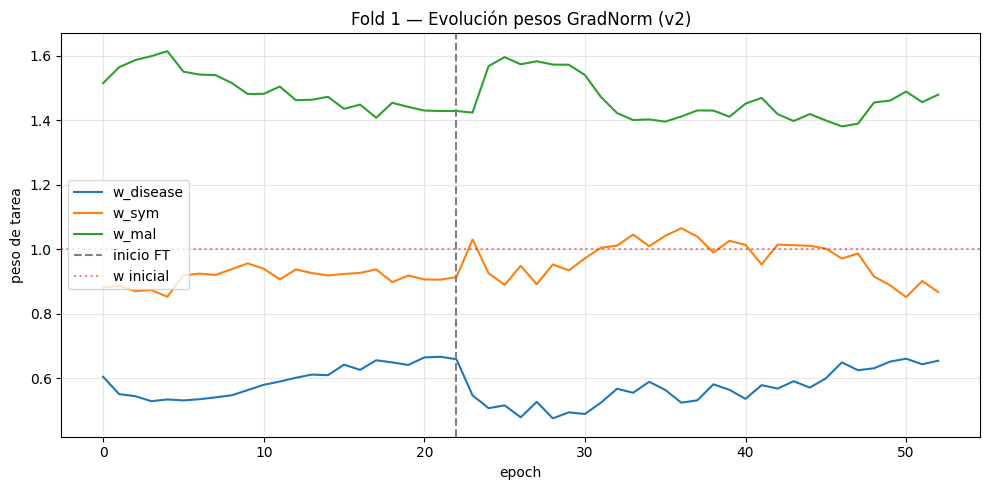


--- Evaluación sobre test (2003 imgs) ---

--- DISEASE ---
              precision    recall  f1-score   support

       akiec     0.5056    0.6818    0.5806        66
         bcc     0.7368    0.6796    0.7071       103
         bkl     0.5681    0.6667    0.6134       219
          df     0.2895    0.4783    0.3607        23
         mel     0.5184    0.6323    0.5697       223
          nv     0.9353    0.8516    0.8915      1341
        vasc     0.7742    0.8571    0.8136        28

    accuracy                         0.7883      2003
   macro avg     0.6183    0.6925    0.6481      2003
weighted avg     0.8147    0.7883    0.7984      2003



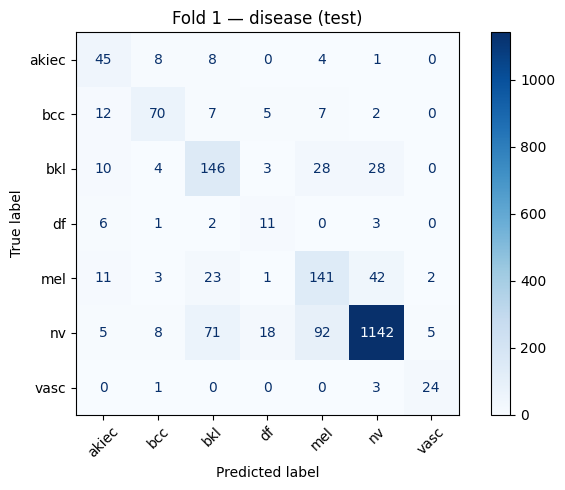


--- SYM ---
              precision    recall  f1-score   support

      2_ejes     0.7630    0.5571    0.6440      1208
       1_eje     0.3631    0.4371    0.3967       604
  asimetrica     0.2411    0.4974    0.3248       191

    accuracy                         0.5152      2003
   macro avg     0.4558    0.4972    0.4552      2003
weighted avg     0.5927    0.5152    0.5390      2003



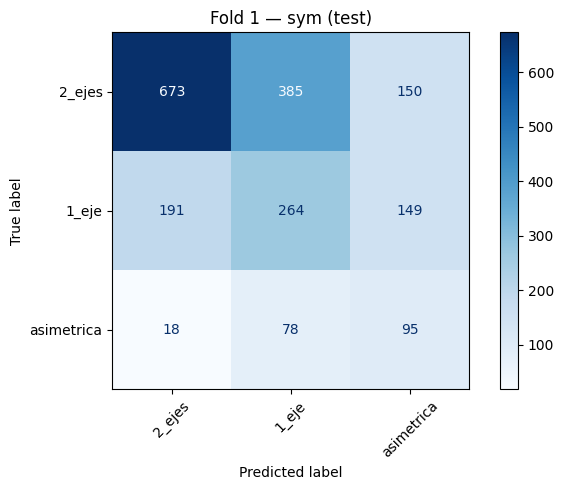


--- MAL ---
              precision    recall  f1-score   support

     benigno     0.9462    0.9063    0.9258      1611
     maligno     0.6717    0.7883    0.7254       392

    accuracy                         0.8832      2003
   macro avg     0.8090    0.8473    0.8256      2003
weighted avg     0.8925    0.8832    0.8866      2003



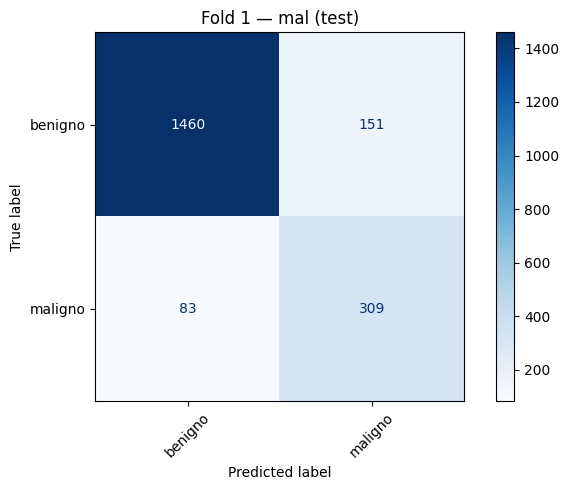

  Pesos guardados en: VGG16_MTL/exp_2026-06-23_20-41_CUT7_5fold_v2/FASE2_final/best_weights

F1 macro test  disease=0.6481  sym=0.4552  mal=0.8256
CSV guardado: VGG16_MTL/exp_2026-06-23_20-41_CUT7_5fold_v2/FASE2_final/predictions_MTL_VGG16_FASE2.csv  (2003 filas)


In [10]:
from sklearn.metrics import precision_score, recall_score

MODEL_TAG = "VGG16"
EXP_DIR_FASE2 = EXP_DIR / "FASE2_final"
EXP_DIR_FASE2.mkdir(parents=True, exist_ok=True)

n_train   = len(df_train)
train_idx = np.arange(n_train)
val_idx   = np.arange(n_train, len(df_trainval))
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(df_test)}")

res = train_one_fold(1, train_idx, val_idx, EXP_DIR_FASE2)


def full_task_metrics(y_true_int, y_pred_int, proba, task, n_cls):
    m = {
        f"{task}_acc":             float((y_true_int == y_pred_int).mean()),
        f"{task}_balanced_acc":    float(balanced_accuracy_score(y_true_int, y_pred_int)),
        f"{task}_precision_macro": float(precision_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_recall_macro":    float(recall_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_f1_macro":        float(f1_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_f1_weighted":     float(f1_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
        f"{task}_kappa":           float(cohen_kappa_score(y_true_int, y_pred_int)),
    }
    try:
        m[f"{task}_auc_macro"] = float(roc_auc_score(np.eye(n_cls)[y_true_int], proba,
                                                       multi_class="ovr", average="macro"))
    except Exception:
        m[f"{task}_auc_macro"] = float("nan")
    return m

metrics = {
    "model":           MODEL_TAG,
    "final_w_disease": res["metrics"]["final_w_disease"],
    "final_w_sym":     res["metrics"]["final_w_sym"],
    "final_w_mal":     res["metrics"]["final_w_mal"],
    "epochs_warmup":   res["metrics"]["epochs_warmup"],
    "epochs_ft":       res["metrics"]["epochs_ft"],
    "time_total_s":    res["metrics"]["time_total_s"],
}
metrics.update(full_task_metrics(y_test_disease_int, res["y_pred_d"], res["y_pred_d_proba"], "disease", NUM_CLASSES))
metrics.update(full_task_metrics(y_test_sym_int,     res["y_pred_s"], res["y_pred_s_proba"], "sym",     NUM_SYM_CLASSES))
metrics.update(full_task_metrics(y_test_mal_int,     res["y_pred_m"], res["y_pred_m_proba"], "mal",     NUM_MAL_CLASSES))
metrics["auc_melanoma"] = float(roc_auc_score((y_test_disease_int == 4).astype(int), res["y_pred_d_proba"][:, 4]))

pd.DataFrame([metrics]).to_csv(EXP_DIR_FASE2 / "metrics_FASE2.csv", index=False)
(EXP_DIR_FASE2 / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
print(f"\nF1 macro test  disease={metrics['disease_f1_macro']:.4f}  "
      f"sym={metrics['sym_f1_macro']:.4f}  mal={metrics['mal_f1_macro']:.4f}")

# CSV imagen a imagen, 3 tareas
df_pred = pd.DataFrame({"image_id": df_test["image_id"].values})
df_pred["disease_true_idx"] = y_test_disease_int; df_pred["disease_pred_idx"] = res["y_pred_d"]
df_pred["disease_true"] = [class_names[i] for i in y_test_disease_int]
df_pred["disease_pred"] = [class_names[i] for i in res["y_pred_d"]]
df_pred["sym_true_idx"] = y_test_sym_int; df_pred["sym_pred_idx"] = res["y_pred_s"]
df_pred["sym_true"] = [sym_names[i] for i in y_test_sym_int]
df_pred["sym_pred"] = [sym_names[i] for i in res["y_pred_s"]]
df_pred["mal_true_idx"] = y_test_mal_int; df_pred["mal_pred_idx"] = res["y_pred_m"]
df_pred["mal_true"] = [mal_names[i] for i in y_test_mal_int]
df_pred["mal_pred"] = [mal_names[i] for i in res["y_pred_m"]]
for j, c in enumerate(class_names): df_pred[f"prob_disease_{c}"] = res["y_pred_d_proba"][:, j]
for j, c in enumerate(sym_names):   df_pred[f"prob_sym_{c}"]     = res["y_pred_s_proba"][:, j]
for j, c in enumerate(mal_names):   df_pred[f"prob_mal_{c}"]     = res["y_pred_m_proba"][:, j]
out_csv = EXP_DIR_FASE2 / f"predictions_MTL_{MODEL_TAG}_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV guardado: {out_csv}  ({len(df_pred)} filas)")